# scraping budgets 

In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from bs4 import BeautifulSoup
import time
import pandas as pd

#path to chrome driver
service=Service('/Users/jocelynegray/Library/Mobile Documents/com~apple~CloudDocs/Downloads/chromedriver-mac-x64/chromedriver')
driver=webdriver.Chrome(service=service)

#creating empty list to store data
all_movies=[]

#url
base_url='https://www.the-numbers.com/movie/budgets/all/'

#loopig through pages
for page_num in range(1, 6001, 100):  
    url=base_url+str(page_num)
    print(f"Scraping page: {url}")
    
    driver.get(url)
    time.sleep(3)

    #parse
    soup=BeautifulSoup(driver.page_source, 'html.parser')

    #finding the table in the webpage
    table=soup.find('table')

    #getting all movie rows from the table (skipping the header)
    rows=table.find_all('tr')[1:]

    #looping through rows and extract desired columns
    for row in rows:
        cols=row.find_all('td')
        
        if len(cols)>1: 
            rank=cols[0].text.strip() 
            release_date=cols[1].text.strip() 
            movie=cols[2].text.strip()  
            production_budget=cols[3].text.strip() 
            domestic_gross=cols[4].text.strip()  
            worldwide_gross=cols[5].text.strip()  

            all_movies.append({'rank': rank,'release_date': release_date,'movie': movie,'production_budget': production_budget,'domestic_gross': domestic_gross,'worldwide_gross': worldwide_gross})


movies_df=pd.DataFrame(all_movies)
movies_df.to_csv('production_budgets_movies.csv', index=False)
print(movies_df.head(20))

driver.quit()


Scraping page: https://www.the-numbers.com/movie/budgets/all/1
Scraping page: https://www.the-numbers.com/movie/budgets/all/101
Scraping page: https://www.the-numbers.com/movie/budgets/all/201
Scraping page: https://www.the-numbers.com/movie/budgets/all/301
Scraping page: https://www.the-numbers.com/movie/budgets/all/401
Scraping page: https://www.the-numbers.com/movie/budgets/all/501
Scraping page: https://www.the-numbers.com/movie/budgets/all/601
Scraping page: https://www.the-numbers.com/movie/budgets/all/701
Scraping page: https://www.the-numbers.com/movie/budgets/all/801
Scraping page: https://www.the-numbers.com/movie/budgets/all/901
Scraping page: https://www.the-numbers.com/movie/budgets/all/1001
Scraping page: https://www.the-numbers.com/movie/budgets/all/1101
Scraping page: https://www.the-numbers.com/movie/budgets/all/1201
Scraping page: https://www.the-numbers.com/movie/budgets/all/1301
Scraping page: https://www.the-numbers.com/movie/budgets/all/1401
Scraping page: https:/

# renaming movie column

In [65]:
df = pd.read_csv('production_budgets_movies.csv')

#renaming the column movies totitle so it matches the other csv
df = df.rename(columns={'movie': 'title'})
df.to_csv('production_budgets_movies.csv', index=False)


# joining budgets with merged movies 

In [67]:

merged_movies = pd.read_csv('merged_movies.csv')
production_budgets = pd.read_csv('production_budgets_movies.csv')

#merging them on the title column
combined_df = pd.merge(merged_movies, production_budgets, on='title', how='inner')

combined_df.to_csv('actors_ratings_budget.csv', index=False)


In [69]:
combined_df=pd.read_csv('actors_ratings_budget.csv')

#dropping rank and release date columns
combined_df=combined_df.drop(columns=['rank', 'release_date'])
combined_df.to_csv('actors_ratings_budget.csv', index=False)


# running regression (audience ratings, star actor, budget)

In [81]:
df=pd.read_csv('combined_movies.csv')

#making sure audience score and production budget are numeric
df['audience_score']=df['audience_score'].str.rstrip('%').astype(float)
df['production_budget']=df['production_budget'].replace({'\$': '', ',': ''}, regex=True).astype(float)
#recreating binary variable 
df['has_star_actor']=df['stars_in_movie'].notna().astype(int)
df=df.dropna(subset=['audience_score', 'production_budget', 'has_star_actor'])

#making the regression 
X=df[['has_star_actor', 'production_budget']]  # independent variables
X=sm.add_constant(X)  # adds an intercept term
y=df['audience_score']  # dependent variable
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:         audience_score   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     10.13
Date:                Wed, 30 Apr 2025   Prob (F-statistic):           4.11e-05
Time:                        13:41:51   Log-Likelihood:                -15028.
No. Observations:                3405   AIC:                         3.006e+04
Df Residuals:                    3402   BIC:                         3.008e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                60.9755      0.48

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
/var/folders/h9/n0byq01s2rn56952m3qk8p800000gn/T/ipykernel_10001/1319833077.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['production_budget']=df['production_budget'].replace({'\$': '', ',': ''}, regex=True).astype(float)


In [85]:
# corr: production_budget and audience_score
correlation_budget_audience=df['production_budget'].corr(df['audience_score'])
print(f"Correlation between production_budget and audience_score: {correlation_budget_audience}")

# Corr: production_budget and star actor
correlation_budget_star_actor=df['production_budget'].corr(df['has_star_actor'])
print(f"Correlation between production_budget and star actor: {correlation_budget_star_actor}")


Correlation between production_budget and audience_score: 0.04245318255314636
Correlation between production_budget and star actor: 0.15363702491927517


In [57]:
#averga budget for films with a star actor and without 
avg_budget_with_star = df[df['has_star_actor']==1]['production_budget'].mean()
avg_budget_without_star = df[df['has_star_actor'] == 0]['production_budget'].mean()

print(f"Average budget (with star actor): ${avg_budget_with_star:,.0f}")
print(f"Average budget (without star actor): ${avg_budget_without_star:,.0f}")



Average budget (with star actor): $54,665,599
Average budget (without star actor): $38,040,130


In [59]:
from scipy.stats import ttest_ind
#getting siginificance of difference between average budgets 
with_star=df[df['has_star_actor']==1]['production_budget'].dropna()
without_star=df[df['has_star_actor'] == 0]['production_budget'].dropna()

t_stat, p_value=ttest_ind(with_star, without_star, equal_var=False)  

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.4f}")


T-statistic: 8.49
P-value: 0.0000


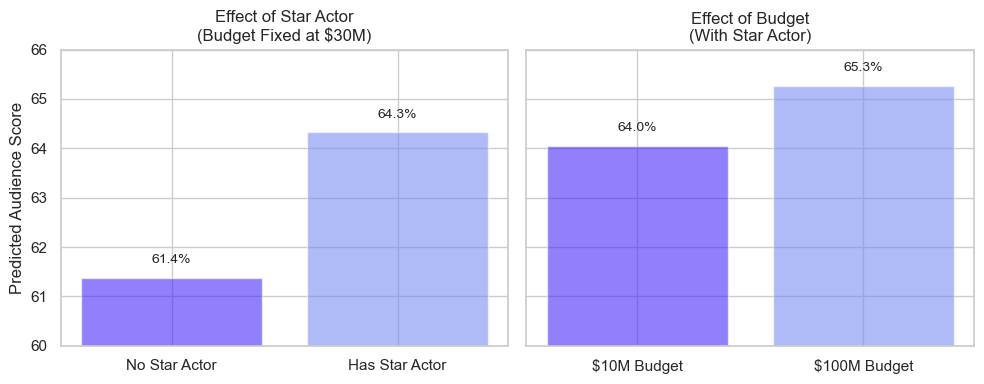

In [53]:
import matplotlib.pyplot as plt
#plotting regression coefficients that i got from the regression i ran
intercept=60.9755
star_effect=2.9373
budget_effect=1.358e-08
#chose budget values for comparison
low_budget=1e7#$10 million
high_budget=1e8#$100 million
#Vary Star Actor, hold budget constant
pred_no_star=intercept+budget_effect*3e7  #chose a$30 million budget
pred_star=pred_no_star+star_effect
# Vary Budget hold star actor constant (assume there is a star actor)
pred_low_budget=intercept+star_effect+budget_effect*low_budget
pred_high_budget=intercept+star_effect +budget_effect*high_budget

#plotting
fig, axes=plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(['No Star Actor', 'Has Star Actor'], [pred_no_star, pred_star], color=['#472BF9', '#7A8EF0'], alpha=0.6)
axes[0].set_title('Effect of Star Actor\n(Budget Fixed at $30M)')
axes[0].set_ylabel('Predicted Audience Score')
axes[0].set_ylim(60, 66)

axes[1].bar(['$10M Budget', '$100M Budget'], [pred_low_budget, pred_high_budget], color=['#472BF9', '#7A8EF0'], alpha=0.6)  
axes[1].set_title('Effect of Budget\n(With Star Actor)')
for ax, values in zip(axes, [[pred_no_star, pred_star], [pred_low_budget, pred_high_budget]]):
    for i, val in enumerate(values):
        ax.text(i, val + 0.3, f"{val:.1f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()
